In [ ]:
import temporal_alignment as ta
import os
from fpdf import FPDF
#r'X:\753126\753126_2024-10-10_14-41-12',
#r'X:\753126\753126_2024-10-14_11-52-34',
'''
parent_directory_1 = 'X:\\'
parent_directory_2 = 'Z:\ephys\Xinxin\Ephys'
#mouse_ids=['708322','713557','713379','722679','722683','726477','713377','716870','741213','741211']
mouse_ids=['764791','769884']
directories=[]
for mouse_id in mouse_ids:
    try:
        current_directory=os.path.join(parent_directory_1,mouse_id)
        directories=directories+[os.path.join(current_directory,f) for f in os.listdir(current_directory) if f.startswith(mouse_id)]
    except:
        current_directory=os.path.join(parent_directory_2,mouse_id)
        directories=directories+[os.path.join(current_directory,f) for f in os.listdir(current_directory) if f.startswith(mouse_id)]
    
'''
directories=[r'X:\769882\769882_2025-01-28_15-09-17']
successes=[]
failures=[]
for directory in directories:
    try:
        pdf1 = FPDF()
        pdf2 = FPDF()

        ta.align_timestamps(directory=directory, original_timestamp_filename="original_timestamps.npy",
            flip_NIDAQ=False,
            local_sync_line=1,
            main_stream_index=0,
            pdf=pdf1)

        ta.align_timestamps_harp(directory=directory,pdf=pdf2)
        successes.append(directory)
    except:
        failures.append(directory)
        print(f"Failed for {directory}")


Loading: I:\753126\753126_2024-10-10_14-41-12\Record Node 103\experiment1\recording1\continuous\Neuropix-PXI-100.ProbeA\timestamps.npy
Loaded data length: 127609099
First timestamp: 3626833.863189409, Last timestamp: 3631087.5490185167
Loading: I:\753126\753126_2024-10-10_14-41-12\Record Node 103\experiment1\recording1\continuous\Neuropix-PXI-100.ProbeB\timestamps.npy
Loaded data length: 127610876
First timestamp: 3626833.8560200743, Last timestamp: 3631087.5487481444
Loading: I:\753126\753126_2024-10-10_14-41-12\Record Node 103\experiment1\recording1\continuous\Neuropix-PXI-100.ProbeA\local_timestamps.npy
Loaded data length: 127609099
First timestamp: -0.750033333334386, Last timestamp: 4252.886566666663
Loading: I:\753126\753126_2024-10-10_14-41-12\Record Node 103\experiment1\recording1\continuous\Neuropix-PXI-100.ProbeB\local_timestamps.npy
Loaded data length: 127610876
First timestamp: -0.7572025850715818, Last timestamp: 4252.886296297147
Loading: I:\753126\753126_2024-10-10_14-41

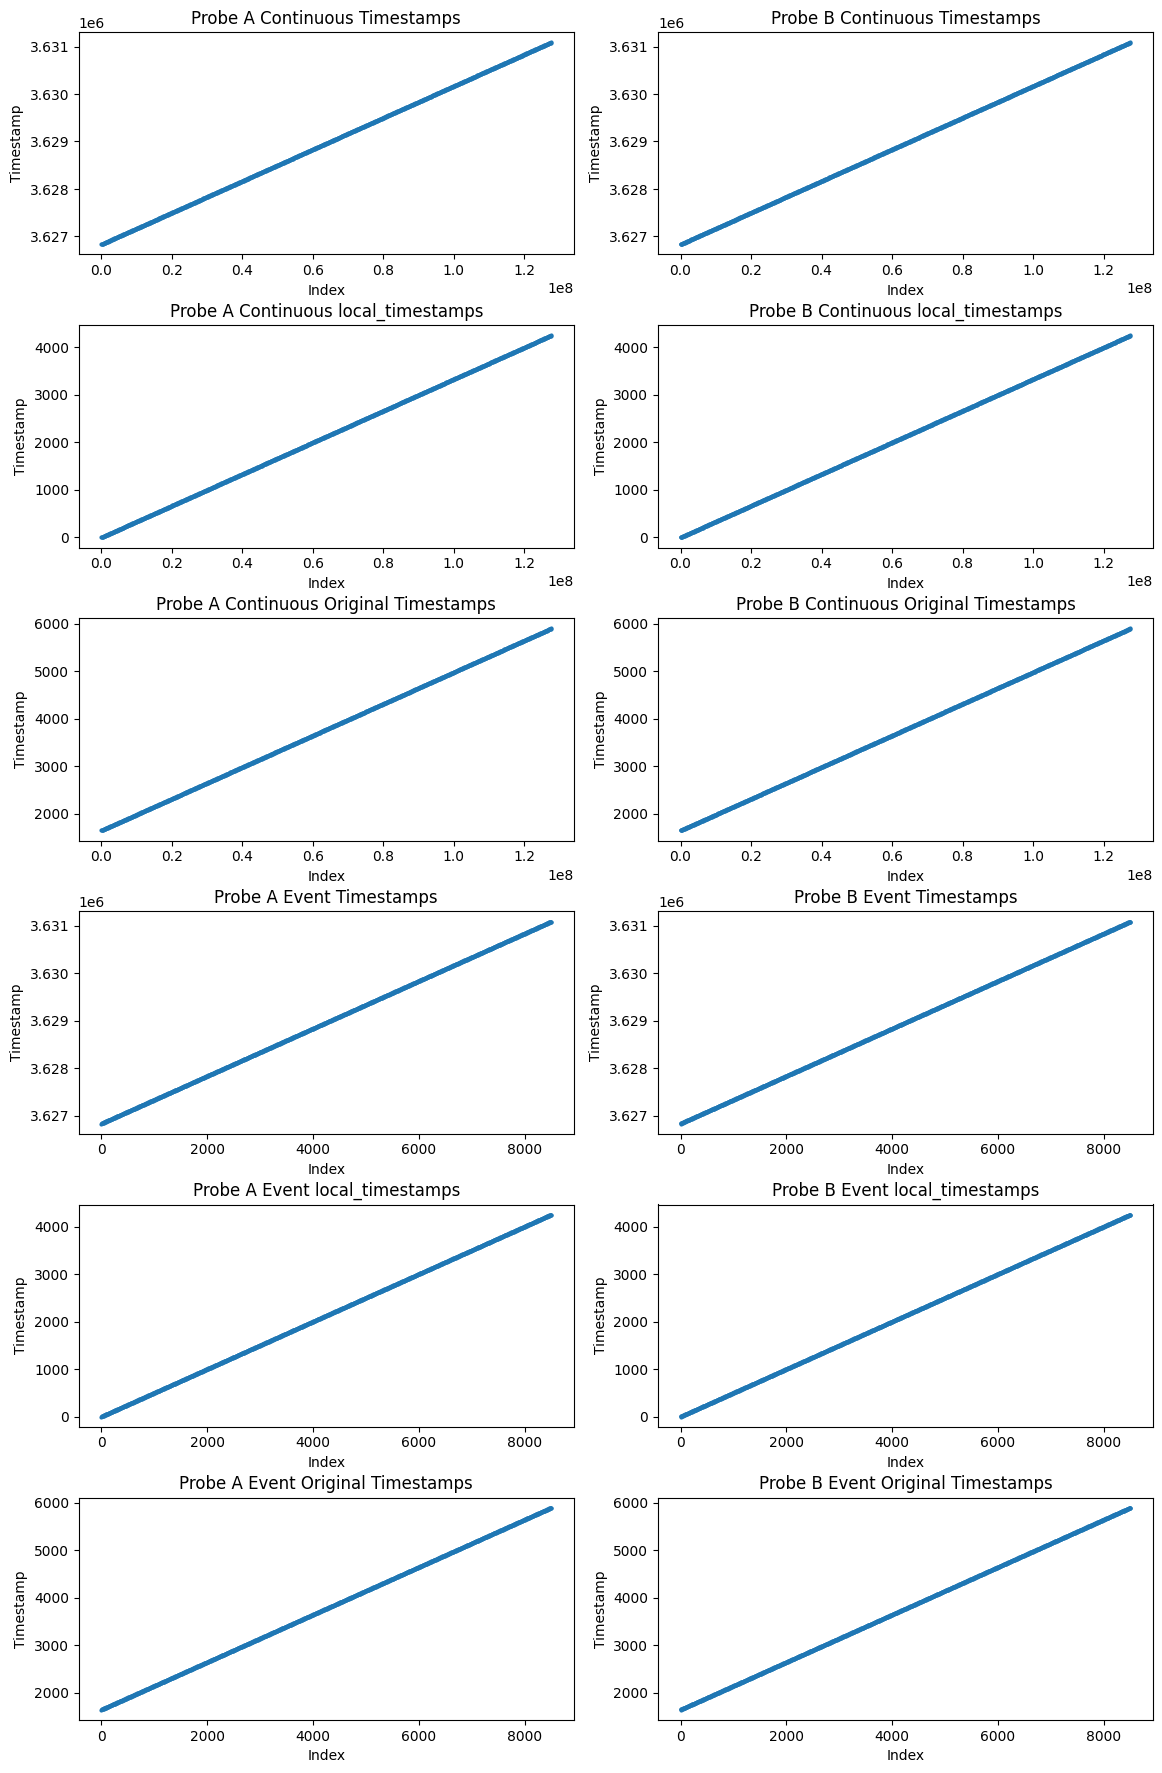

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# Helper functions
# --------------------------
def load_if_exists(file_path):
    """
    Load a .npy file if it exists; otherwise, print a warning and return None.
    If the file is loaded, print the array length and the first and last timestamp.
    """
    if os.path.exists(file_path):
        print("Loading:", file_path)
        data = np.load(file_path)
        if data is not None:
            print(f"Loaded data length: {len(data)}")
            if len(data) > 0:
                print(f"First timestamp: {data[0]}, Last timestamp: {data[-1]}")
        return data
    else:
        print("File does not exist:", file_path)
        return None

def check_abnormal_timestamps(data, label, context_window=10):
    """
    Check if the timestamp array is strictly increasing.
    If not, print the indices where the timestamp decreases and also print
    the surrounding timestamps (context) for each abnormal point.
    
    Parameters:
        data: 1D array of timestamps.
        label: A label to identify which data array is being checked.
        context_window: How many points before and after the abnormal point to print.
    """
    if data is None:
        print(f"{label}: No data available to check.")
        return None
    if len(data) < 2:
        print(f"{label}: Not enough data points to check monotonicity.")
        return None

    # Compute differences between consecutive timestamps.
    diffs = np.diff(data)
    # Find indices where the difference is negative.
    abnormal_idx = np.where(diffs < 0)[0]
    if abnormal_idx.size > 0:
        # The abnormal point is considered to be at index+1 (where the drop occurs)
        abnormal_points = abnormal_idx + 1
        print(f"{label}: Abnormal timestamps detected at indices {abnormal_points}.")
        for idx in abnormal_points:
            # Determine context indices (ensuring we do not go out of bounds)
            start = max(0, idx - context_window)
            end = min(len(data), idx + context_window + 1)
            print(f"Context around abnormal index {idx}:")
            for j in range(start, end):
                print(f"  Index {j}: timestamp = {data[j]}")
    else:
        print(f"{label}: Timestamps are monotonically increasing.")
    return abnormal_idx

def plot_timestamp(ax, data, title, max_points=1000):
    """
    Plot a 1D timestamp array on the given axis with a title.
    
    To accelerate plotting, if the number of points exceeds max_points,
    only a subset (every nth point) is plotted.
    
    Abnormal (non-monotonic) points that happen to fall on the sampled
    indices are marked in red.
    """
    if data is not None:
        n_points = len(data)
        if n_points > max_points:
            step = max(1, n_points // max_points)
            indices = np.arange(0, n_points, step)
            sampled_data = data[indices]
        else:
            indices = np.arange(n_points)
            sampled_data = data

        # Plot the (downsampled) data.
        ax.plot(indices, sampled_data, marker='o', linestyle='-', markersize=2, label='Timestamp')
        
        # Compute abnormal indices on the full data.
        diffs = np.diff(data)
        abnormal_full = np.where(diffs < 0)[0] + 1  # indices in the full data array

        # Find abnormal indices that are included in our down-sampled indices.
        abnormal_in_sample = np.intersect1d(indices, abnormal_full)
        if abnormal_in_sample.size > 0:
            ax.plot(abnormal_in_sample, data[abnormal_in_sample], 'ro', markersize=5, label='Abnormal Timestamp')
            ax.legend()
    else:
        ax.text(0.5, 0.5, "Data not available",
                horizontalalignment='center', verticalalignment='center',
                transform=ax.transAxes)
    ax.set_title(title)
    ax.set_xlabel("Index")
    ax.set_ylabel("Timestamp")


# --------------------------
# Set up folder and file names
# --------------------------
session_folder = r'I:\753126\753126_2024-10-14_11-52-34'  # seems to be correct
session_folder = r'I:\753126\753126_2024-10-10_14-41-12'
#session_folder = r'I:\764787\764787_2024-12-11_15-01-07'  # seems to be correct, but there are negative values in the local timestamps 
#session_folder = r'I:\764790\764790_2024-12-19_16-11-28'  # seems to be correct, but there are negative values in the local timestamps 
#session_folder = r'X:\769884\769884_2025-01-15_16-12-54' # not aligned
#session_folder = r'X:\769884\769884_2025-01-16_18-33-07'
#session_folder = r'I:\753126\753126_2024-10-10_14-41-12'
#session_folder = r'I:\753125\753125_2024-10-09_10-50-07'

# Choose which set of local timestamps to use for continuous and event data.
name = 'local_timestamps'
# Define an additional variable for the original timestamps to load separately.
original_name = 'original_timestamps'

# --------------------------
# Define probe folders (continuous data)
# --------------------------
probeA_folder = os.path.join(session_folder, r"Record Node 103\experiment1\recording1\continuous\Neuropix-PXI-100.ProbeA")
probeB_folder = os.path.join(session_folder, r"Record Node 103\experiment1\recording1\continuous\Neuropix-PXI-100.ProbeB")

# --------------------------
# Continuous (probe) file paths
# --------------------------
# Standard timestamps
probeA_timestamps_path = os.path.join(probeA_folder, "timestamps.npy")
probeB_timestamps_path = os.path.join(probeB_folder, "timestamps.npy")

# Local timestamps (using variable "name")
probeA_local_timestamps_path = os.path.join(probeA_folder, f"{name}.npy")
probeB_local_timestamps_path = os.path.join(probeB_folder, f"{name}.npy")

# Additional original timestamps
probeA_original_timestamps_path = os.path.join(probeA_folder, f"{original_name}.npy")
probeB_original_timestamps_path = os.path.join(probeB_folder, f"{original_name}.npy")

# --------------------------
# Event file paths
# --------------------------
# Standard event timestamps
probeA_event_timestamps_path = os.path.join(session_folder, r"Record Node 103\experiment1\recording1\events\Neuropix-PXI-100.ProbeA\TTL\timestamps.npy")
probeB_event_timestamps_path = os.path.join(session_folder, r"Record Node 103\experiment1\recording1\events\Neuropix-PXI-100.ProbeB\TTL\timestamps.npy")

# Event local timestamps (using variable "name")
probeA_event_local_timestamps_path = os.path.join(session_folder, r"Record Node 103\experiment1\recording1\events\Neuropix-PXI-100.ProbeA\TTL\local_timestamps.npy")
probeB_event_local_timestamps_path = os.path.join(session_folder, r"Record Node 103\experiment1\recording1\events\Neuropix-PXI-100.ProbeB\TTL\local_timestamps.npy")

# Event original timestamps
probeA_event_original_timestamps_path = os.path.join(session_folder, r"Record Node 103\experiment1\recording1\events\Neuropix-PXI-100.ProbeA\TTL\original_timestamps.npy")
probeB_event_original_timestamps_path = os.path.join(session_folder, r"Record Node 103\experiment1\recording1\events\Neuropix-PXI-100.ProbeB\TTL\original_timestamps.npy")

# --------------------------
# Load all timestamp arrays using our helper function
# --------------------------
# Continuous (probe) timestamps
probeA_timestamps = load_if_exists(probeA_timestamps_path)
probeB_timestamps = load_if_exists(probeB_timestamps_path)

probeA_local_timestamps = load_if_exists(probeA_local_timestamps_path)
probeB_local_timestamps = load_if_exists(probeB_local_timestamps_path)

probeA_original_timestamps = load_if_exists(probeA_original_timestamps_path)
probeB_original_timestamps = load_if_exists(probeB_original_timestamps_path)

# Event timestamps
probeA_event_timestamps = load_if_exists(probeA_event_timestamps_path)
probeB_event_timestamps = load_if_exists(probeB_event_timestamps_path)

probeA_event_local_timestamps = load_if_exists(probeA_event_local_timestamps_path)
probeB_event_local_timestamps = load_if_exists(probeB_event_local_timestamps_path)

probeA_event_original_timestamps = load_if_exists(probeA_event_original_timestamps_path)
probeB_event_original_timestamps = load_if_exists(probeB_event_original_timestamps_path)

# --------------------------
# Check for abnormal timestamps (console output)
# --------------------------
print("\n--- Continuous Timestamps Check ---")
check_abnormal_timestamps(probeA_timestamps, "Probe A Continuous Timestamps", context_window=1)
check_abnormal_timestamps(probeA_local_timestamps, f"Probe A Continuous {name}", context_window=1)
check_abnormal_timestamps(probeA_original_timestamps, "Probe A Continuous Original Timestamps", context_window=1)

check_abnormal_timestamps(probeB_timestamps, "Probe B Continuous Timestamps", context_window=1)
check_abnormal_timestamps(probeB_local_timestamps, f"Probe B Continuous {name}", context_window=1)
check_abnormal_timestamps(probeB_original_timestamps, "Probe B Continuous Original Timestamps", context_window=1)

print("\n--- Event Timestamps Check ---")
check_abnormal_timestamps(probeA_event_timestamps, "Probe A Event Timestamps", context_window=1)
check_abnormal_timestamps(probeA_event_local_timestamps, f"Probe A Event {name}", context_window=1)
check_abnormal_timestamps(probeA_event_original_timestamps, "Probe A Event Original Timestamps", context_window=1)

check_abnormal_timestamps(probeB_event_timestamps, "Probe B Event Timestamps", context_window=1)
check_abnormal_timestamps(probeB_event_local_timestamps, f"Probe B Event {name}", context_window=1)
check_abnormal_timestamps(probeB_event_original_timestamps, "Probe B Event Original Timestamps", context_window=1)

# --------------------------
# Plotting all timestamp arrays
# --------------------------
# Create a grid of subplots:
# - Rows 0-2: Continuous (probe) timestamps (Standard, local, and original)
# - Rows 3-5: Event timestamps (Standard, local, and original)
# Each row has 2 columns: Probe A (left) and Probe B (right)
fig, axs = plt.subplots(nrows=6, ncols=2, figsize=(12, 18))
fig.tight_layout(pad=3.0)

# --- Continuous Data Plots ---
# Row 0: Standard continuous timestamps
plot_timestamp(axs[0, 0], probeA_timestamps, "Probe A Continuous Timestamps")
plot_timestamp(axs[0, 1], probeB_timestamps, "Probe B Continuous Timestamps")

# Row 1: Continuous local timestamps
plot_timestamp(axs[1, 0], probeA_local_timestamps, f"Probe A Continuous {name}")
plot_timestamp(axs[1, 1], probeB_local_timestamps, f"Probe B Continuous {name}")

# Row 2: Continuous original timestamps
plot_timestamp(axs[2, 0], probeA_original_timestamps, "Probe A Continuous Original Timestamps")
plot_timestamp(axs[2, 1], probeB_original_timestamps, "Probe B Continuous Original Timestamps")

# --- Event Data Plots ---
# Row 3: Standard event timestamps
plot_timestamp(axs[3, 0], probeA_event_timestamps, "Probe A Event Timestamps")
plot_timestamp(axs[3, 1], probeB_event_timestamps, "Probe B Event Timestamps")

# Row 4: Event local timestamps
plot_timestamp(axs[4, 0], probeA_event_local_timestamps, f"Probe A Event {name}")
plot_timestamp(axs[4, 1], probeB_event_local_timestamps, f"Probe B Event {name}")

# Row 5: Event original timestamps
plot_timestamp(axs[5, 0], probeA_event_original_timestamps, "Probe A Event Original Timestamps")
plot_timestamp(axs[5, 1], probeB_event_original_timestamps, "Probe B Event Original Timestamps")

plt.show()
